# 1. Data Preparation & Exploratory Analysis

In [222]:
# ============================================================
# Core Data Handling and Numerical Computing
# ============================================================

import numpy as np                  # Numerical computing
import pandas as pd                 # Data manipulation and analysis


# ============================================================
# Scikit-Learn: Preprocessing and Pipelines
# ============================================================

from sklearn.compose import ColumnTransformer      # Column-wise preprocessing
from sklearn.pipeline import Pipeline              # ML pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer           # Missing value handling


# ============================================================
# Scikit-Learn: Model Selection and Validation
# ============================================================

from sklearn.model_selection import (
    train_test_split,               # Train-test splitting
    KFold,                          # K-fold cross-validation
    StratifiedKFold,                # Stratified CV (mainly for classification)
    GridSearchCV,                   # Hyperparameter tuning
    cross_val_score                 # Cross-validation scoring
)


# ============================================================
# Scikit-Learn: Models and Custom Estimators
# ============================================================

from sklearn.linear_model import LinearRegression   # Baseline regression model
from sklearn.base import BaseEstimator, RegressorMixin  # Custom estimator support


# ============================================================
# Scikit-Learn: Evaluation Metrics
# ============================================================

from sklearn.metrics import mean_squared_error, r2_score


# ============================================================
# Visualization and Plotting
# ============================================================

import matplotlib.pyplot as plt     # Core plotting
import seaborn as sns               # Statistical visualization

from IPython.display import Image   # Display images in notebooks

from mlxtend.plotting import (
    scatterplotmatrix,              # Feature relationship plots
    heatmap                         # Correlation heatmaps
)


# ============================================================
# Reproducibility
# ============================================================

from numpy.random import seed        # Set random seed


# ============================================================
# Model Persistence (Saving/Loading Models)
# ============================================================

import pickle                        # Save trained models

### 1 (a)

In [223]:
df = pd.read_csv('crime.csv')
df.head()

,state,murder.rate,poverty,high.school,college,single.parent,unemployed,metropolitan,region
0,Alabama,7.4,14.7,77.5,20.4,26.0,4.6,70.2,South
1,Alaska,4.3,8.4,90.4,28.1,23.2,6.6,41.6,West
2,Arizona,7.0,13.5,85.1,24.6,23.5,3.9,87.9,West
3,Arkansas,6.3,15.8,81.7,18.4,24.7,4.4,49.0,South
4,California,6.1,14.0,81.2,27.5,21.8,4.9,96.7,West


### 1 (b)

In [224]:
df.describe(include=['float64'])

,murder.rate,poverty,high.school,college,single.parent,unemployed,metropolitan
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,4.604000,11.440000,85.482000,24.932000,22.970000,3.904000,67.726000
std,2.510221,2.937096,3.959782,4.312319,3.038814,0.947383,20.562099
min,0.600000,7.300000,77.100000,15.300000,13.600000,2.200000,27.900000
25%,2.600000,9.425000,82.525000,22.525000,20.950000,3.225000,49.800000
50%,4.550000,10.550000,86.100000,24.450000,22.800000,3.900000,70.250000
75%,6.300000,13.375000,88.175000,27.450000,24.575000,4.400000,84.375000
max,12.500000,19.300000,91.800000,34.600000,30.000000,6.600000,100.000000


### 1 (c)

In [225]:
df.isnull().sum()

state            0
murder.rate      0
poverty          0
high.school      0
college          0
single.parent    0
unemployed       0
metropolitan     0
region           0
dtype: int64

In [226]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print("\nMissing percentage:")
print(missing_pct)


Missing percentage:
state            0.0
murder.rate      0.0
poverty          0.0
high.school      0.0
college          0.0
single.parent    0.0
unemployed       0.0
metropolitan     0.0
region           0.0
dtype: float64


If we had missing values, we would use imputation of the median for numeric values and mode for categorical values.

### 1 (d)

(<Figure size 640x480 with 2 Axes>, <Axes: >)

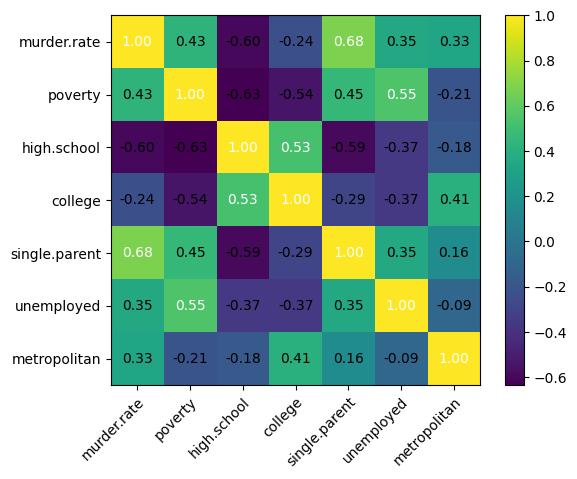

In [227]:
numeric_features = df.select_dtypes(include=['float64']).columns
cm=df[numeric_features].corr().values
heatmap(cm, row_names=numeric_features, column_names=numeric_features)

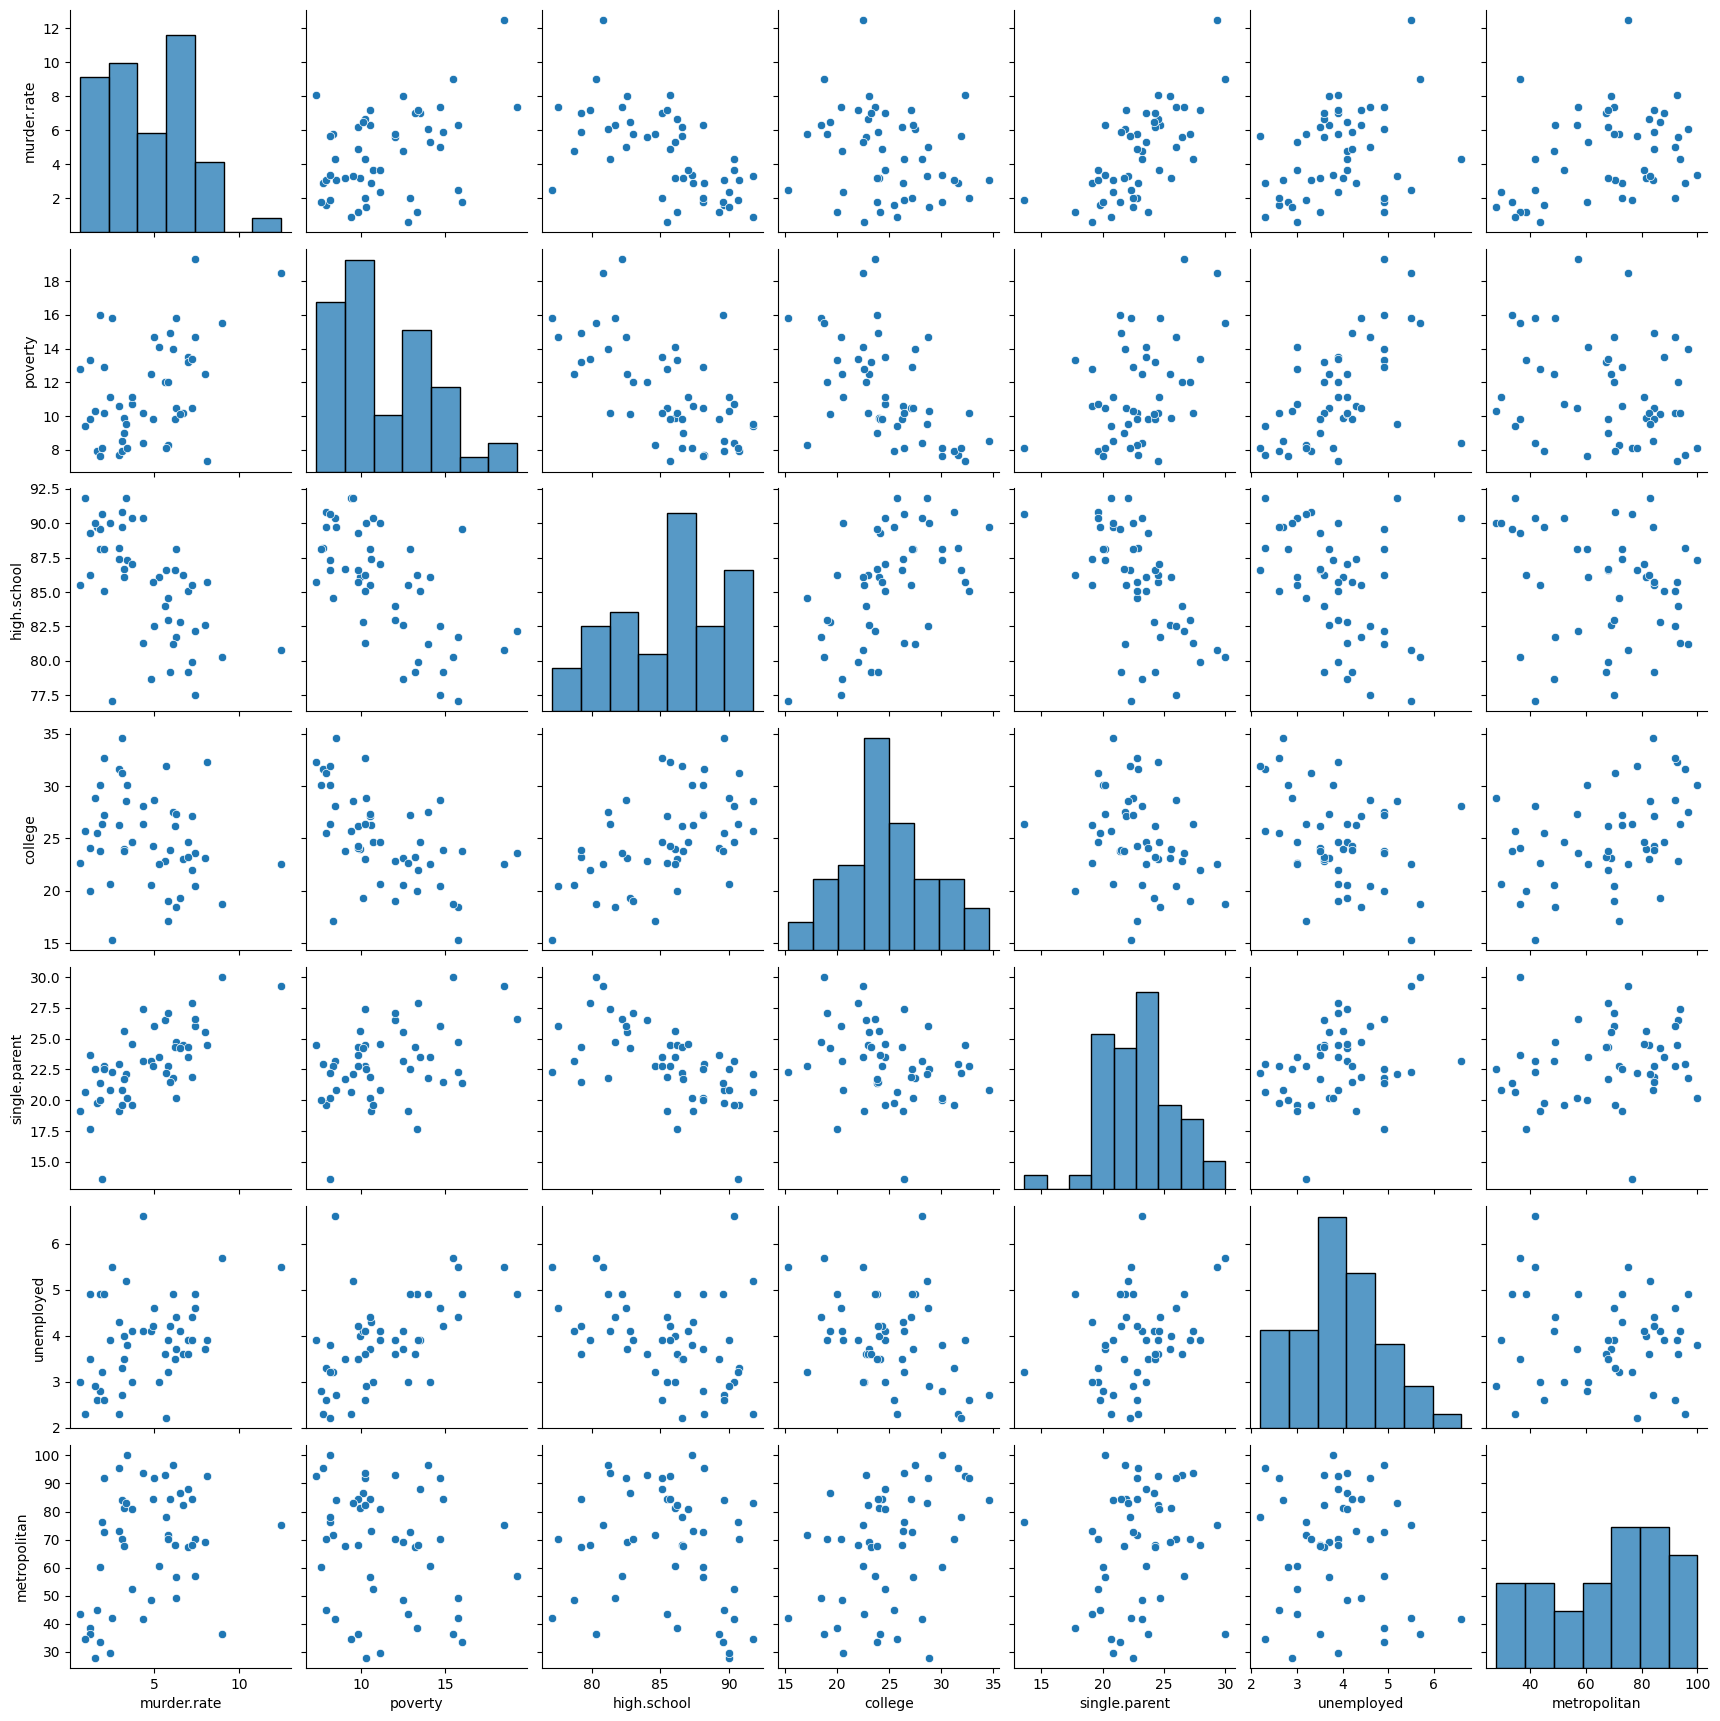

In [228]:
sns.pairplot(df)

Comparing pairplot and heatmap, the heatmap is clearer to find out the correlation between features. 
pairplot is more useful to for visually examining how two variables interact and how their values change together.
murder.rate and single.parent has strong positive correlationship on heatmap , which is also reflected in the pairplot where both variables increase together. 
 And high school graduation rate and poverty have a negative correlation. It's make sense when looking at the the plots. 
 as higher graduation rates tend to be associated with lower poverty levels.
 And they also have correlationship between highschool and poverty.

### 1 (e)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'murder.rate'),
  Text(1, 0, 'poverty'),
  Text(2, 0, 'high.school'),
  Text(3, 0, 'college'),
  Text(4, 0, 'single.parent'),
  Text(5, 0, 'unemployed'),
  Text(6, 0, 'metropolitan')])

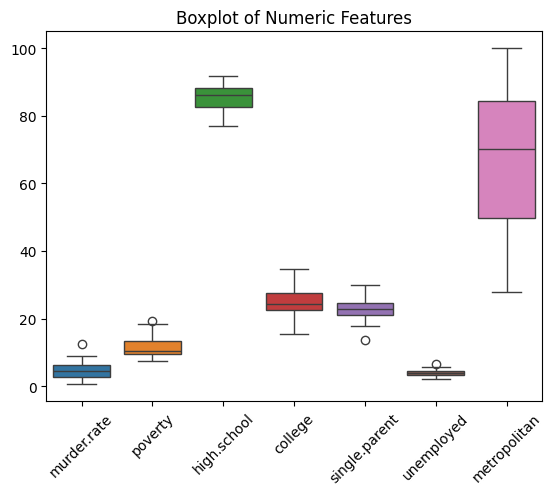

In [229]:
sns.boxplot(data=df[numeric_features])
plt.title('Boxplot of Numeric Features')
plt.xticks(rotation=45)

In [230]:
Q1 = df['murder.rate'].quantile(0.25)
Q3 = df['murder.rate'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


In [231]:
outliers = df[(df['murder.rate'] < lower) | (df['murder.rate'] > upper)]
outliers[['state', 'murder.rate']]


,state,murder.rate
17,Lousiana,12.5


In [232]:
numeric_cols = ['murder.rate', 'poverty', 'high.school', 'college', 'single.parent', 'unemployed', 'metropolitan']
outliers_df1 = []
outliers_df2 = []
for col in numeric_cols: 
    Q1 = df[col].quantile(0.25) 
    Q3 = df[col].quantile(0.75) 
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_df1.append(outliers[['state', col]])
    outliers_df2.append(outliers)

outliers_df1 = pd.concat(outliers_df1, ignore_index=True) #to make it clear, make dateframe
outliers_df2 = pd.concat(outliers_df2, ignore_index=True)   


In [233]:
outliers_df1 #select to show what columns have outliers

,state,murder.rate,poverty,high.school,college,single.parent,unemployed,metropolitan
0,Lousiana,12.5,NaN,NaN,NaN,NaN,NaN,NaN
1,New_Mexico,NaN,19.3,NaN,NaN,NaN,NaN,NaN
2,Utah,NaN,NaN,NaN,NaN,13.6,NaN,NaN
3,Alaska,NaN,NaN,NaN,NaN,NaN,6.6,NaN


In [234]:
outliers_df2 #select all

,state,murder.rate,poverty,high.school,college,single.parent,unemployed,metropolitan,region
0,Lousiana,12.5,18.5,80.8,22.5,29.3,5.5,75.2,South
1,New_Mexico,7.4,19.3,82.2,23.6,26.6,4.9,57.0,West
2,Utah,1.9,8.1,90.7,26.4,13.6,3.2,76.4,West
3,Alaska,4.3,8.4,90.4,28.1,23.2,6.6,41.6,West


Using the IQR rule, several observations were flagged as outliers. However, the IQR method only identifies values that are statistically distant from the center of the distribution; 
it does not determine whether these values are erroneous or meaningful. All detected outliers fall within normal and physically possible ranges (0–100 for percentage-based variables), 
and none deviate excessively from the main distribution. After identifying which states produced these values, I found that each outlier corresponds to a well‑known real‑world characteristic of that state (e.g., high murder rate in Louisiana, high poverty in New Mexico, low single‑parent rate in Utah, and high unemployment in Alaska). Because these values are realistic and explainable rather than errors, I chose to retain them. To further understand the relationships among these extreme cases, I generated a separate heatmap using only the outlier subset.

<Axes: >

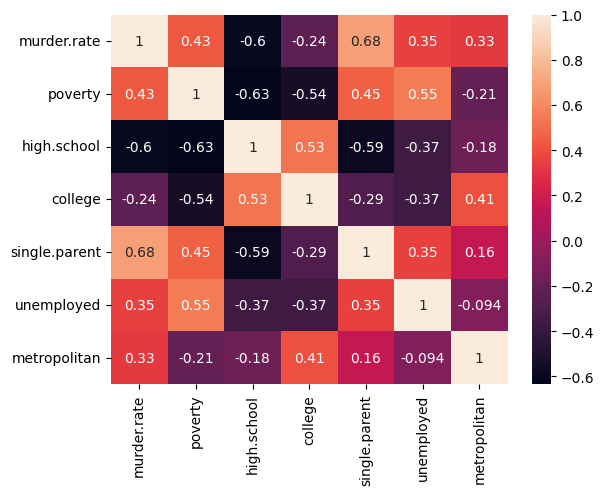

In [235]:
numeric_features_outlier = outliers_df2.select_dtypes(include=['float64']).columns.tolist()
cm1=df[numeric_features_outlier].corr()
sns.heatmap(cm1, annot=True,xticklabels=numeric_features_outlier, yticklabels=numeric_features_outlier)
#heatmap of ouliers. It show similar correlationship with origin group. So I will not remove the outliers

# 2. Scikit-learn Baseline Pipeline

a) Build a Pipeline that integrates a ColumnTransformer with the following steps in order:

• Missing-value imputation (median strategy for numeric features).

• One-hot encoding for region (with drop='first' to avoid multicollinearity).

• Standardization of all numeric features using StandardScaler.

• scikit-learn’s LinearRegression estimator.


In [236]:
df.columns

Index(['state', 'murder.rate', 'poverty', 'high.school', 'college',
       'single.parent', 'unemployed', 'metropolitan', 'region'],
      dtype='object')

In [237]:
x = df.drop(['murder.rate', 'state'],axis=1)
y = df['murder.rate'] #this column will be used as the target variable

In [238]:
x.head()

,poverty,high.school,college,single.parent,unemployed,metropolitan,region
0,14.7,77.5,20.4,26.0,4.6,70.2,South
1,8.4,90.4,28.1,23.2,6.6,41.6,West
2,13.5,85.1,24.6,23.5,3.9,87.9,West
3,15.8,81.7,18.4,24.7,4.4,49.0,South
4,14.0,81.2,27.5,21.8,4.9,96.7,West


### 2 (b)

In [239]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=.50, random_state=42)

In [240]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
numeric_features

Index(['poverty', 'high.school', 'college', 'single.parent', 'unemployed',
       'metropolitan'],
      dtype='object')

In [241]:
categorical_features=X_train.select_dtypes(include=['object']).columns
categorical_features

Index(['region'], dtype='object')

In [242]:
num_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                        ('Scaler', StandardScaler())])

In [243]:
cat_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                               ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))])
                               #One-hot encoding for region (with drop=’first’ to avoid multicollinearity)

In [244]:
preprocessor = ColumnTransformer(transformers=[('num',num_pipeline,numeric_features), ('cat',cat_pipeline,categorical_features)])

In [245]:
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [246]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])


### 2 (b) continued

In [247]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [248]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [249]:
# Calculate R2 and RMSE for both training and test splits (check for differences in performance between the two)
#r2 = 1 - (sum of squared errors / sum of squared deviations from the mean)
#y_train_pred and y_test_pred are the predicted values from the model for the y_train and y_test sets, respectively.



train_r2_scores = r2_score(y_train,y_train_pred)
sklearn_test_r2_scores = r2_score(y_test,y_test_pred)
train_rmse_scores = np.sqrt(mean_squared_error(y_train,y_train_pred))
sklearn_test_rmse_scores = np.sqrt(mean_squared_error(y_test,y_test_pred))

In [250]:
print(f"R2 training score: {train_r2_scores:.4f}")
print(f"R2 testing score: {sklearn_test_r2_scores:.4f}")
print(f"RMSE training score: {train_rmse_scores:.4f}")
print(f"RMSE testing score: {sklearn_test_rmse_scores:.4f}")

R2 training score: 0.7496
R2 testing score: 0.3021
RMSE training score: 1.1517
RMSE testing score: 1.8506


### 2 (c)

In [251]:
cv_pipeline = Pipeline([('preprocessor', preprocessor),
                        ('regressor', LinearRegression())])

In [252]:
from sklearn.model_selection import cross_validate

#Keys ('r2', 'neg_mse') are custom names for the output,
# and values ('r2', 'neg_mean_squared_error') tell scikit-learn
# which built-in scoring functions to compute.

scoring_metrics = {
    'r2': 'r2',
    'neg_mse': 'neg_mean_squared_error'
}
# 3-fold cross-validation /
# cv=3 is for making 3-fold which provides a good balance between bias and variance in the performance estimates. 
# It means the data will be split into 3 subsets, and the model will be trained and evaluated 3 times, each time using a different subset as the test set and the remaining two subsets as the training set.
cv_results = cross_validate(cv_pipeline, X_train, y_train, 
                            cv=3, scoring=scoring_metrics)

# R2 mean & std of 3-fold cross-validation results
sklearn_cv_r2_mean = cv_results['test_r2'].mean()
cv_r2_std = cv_results['test_r2'].std()

# RMSE mean & std (neg_mse → mse → rmse)
sklearn_cv_rmse_mean = np.sqrt(-cv_results['test_neg_mse']).mean()
cv_rmse_std = np.sqrt(-cv_results['test_neg_mse']).std()

print(f"Mean CV R2: {sklearn_cv_r2_mean:.4f}, Standard Deviation: {cv_r2_std:.4f}")
print(f"Mean CV RMSE: {sklearn_cv_rmse_mean:.4f}, Standard Deviation: {cv_rmse_std:.4f}")

Mean CV R2: -0.7235, Standard Deviation: 0.5672
Mean CV RMSE: 2.6562, Standard Deviation: 0.2427


### 2 (d)

The simple train/test resulted in an r2 score of 0.749 for training and only 0.302 for testing, with RMSE values of 1.1517 for training and 1.8506 for testing. This gap shows that the model fits the training data reasonably well but generalizes poorly to unseen data. As both the R² drops and the RMSE increases on the test set.
In contrast, the 3‑fold cross‑validation approach produced a mean R² of –0.7235 which means the model is worse than using the mean value to make predictions. And a standard deviation of 0.5672 suggests that performance is quite unstable across different folds—likely due to the small sample size (50 observations)

The cross validation score is more reliable because it splits the data up into different training/testing sets to get a more robust picture of how the model is performing and allows us to average the scores accross the different folds.

# 3.Mini-BatchGradientDescentfromScratch

## 3.1 Implementation Requirements

In [276]:
import numpy as np
from sklearn.base import BaseEstimator , RegressorMixin
from sklearn.exceptions import NotFittedError
# Needed to pass check_estimator
from sklearn.utils.validation import check_is_fitted, check_X_y, validate_data
from sklearn.utils.multiclass import type_of_target
from sklearn.utils import check_array

class LinearRegressionGD ( RegressorMixin, BaseEstimator ) :
    """Gradient descent linear regression (full-batch starting point)."""
    def __init__(self, eta=0.01, n_iter=50, batch_size=8, random_state=1):
        self.eta = eta #eta == learning rate
        self.n_iter = n_iter #n_iter = epochs 
#epochs are the number of times the entire training dataset is passed through the model during training.
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y):
        # Added to pass check_estimator
        # Checks the input number of features is consistent
        X, y = validate_data(self, X, y)
        # Rejects sparse data
        X, y = check_X_y(X, y, accept_sparse=False)
        # Checks for 'unknown' y labels
        target_type = type_of_target(y, raise_unknown=True)
        if target_type not in ['continuous', 'continuous-multioutput', 'multiclass', 'binary']:
            raise ValueError(f"Unknown label type: {target_type}. Expected continuous values.")
        #verify that X and y are numpy arrays and have correct shapes
        X = np.asarray(X)  # convert to numpy array
        y = np.asarray(y)  # convert to numpy array

        
        #2) Store the number of features     
        self.n_features_in_ = X.shape[1]
        #3) initialize weights and bias
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])  # X.shape[1] == the number of features
        self.b_ = np.array([0.])
        self.losses_ = []
        self.n_features_in_ = X.shape[1]  # required for sklearn validation
        #4) the number of samples in the dataset
        n_samples = X.shape[0]  

        #5) Learning logic
        for epoch in range(self.n_iter):
            # 1) shuffle to prevent cycles
            indices = rgen.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_losses = []
           
            #2) mini-batch gradient descent
            for start in range(0, n_samples, self.batch_size):
                # starting 0, then indexing the size of batch(0, 8, 16, ...) until it reaches the number of samples.
                end = start + self.batch_size
                # Draw batch <X_batch, y_batch> ⊂ D
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                # Compute loss L
                output = self.net_input(X_batch)
                errors = (y_batch - output)
                loss = (errors ** 2).mean()
                epoch_losses.append(loss)
                
                # Compute gradients Δw, Δb and update parameters
                self.w_ += self.eta * 2.0 * X_batch.T.dot(errors) / X_batch.shape[0]
                self.b_ += self.eta * 2.0 * errors.mean()
            #3) Store the average MSE for each epoch to list
            self.losses_.append(np.mean(epoch_losses))
         #4) 'is_fitted_' is a flag for checking if the model is fitted
        self.is_fitted_ = True 
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_


    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_


    def predict(self, X):
        # Added to pass check_estimator
        # Checks that the model is fitted before making a prediction
        check_is_fitted(self, ['w_', 'b_', 'n_features_in_'])
        # Checks the input number of features are consistent
        X = validate_data(self, X, reset=False)
        # Rejects sparse data
        X = check_array(X, accept_sparse=False)
        
        return self.net_input(X)   

In [277]:
# Check that the model passees the "check_estimator"
from sklearn.utils.estimator_checks import check_estimator

model = LinearRegressionGD()
try:
    check_estimator(model)
    print("Check passed!")
except Exception as e:
    print(f"Check failed: {e}")

Check passed!


c:\Users\Juhee.DESKTOP-KKC64G0\Documents\DeepLearning\Demo\datascienceintro\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19736\996147288.py:63: RuntimeWarning: overflow encountered in square
  loss = (errors ** 2).mean()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19736\996147288.py:67: RuntimeWarning: overflow encountered in dot
  self.w_ += self.eta * 2.0 * X_batch.T.dot(errors) / X_batch.shape[0]
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19736\996147288.py:67: RuntimeWarning: invalid value encountered in add
  self.w_ += self.eta * 2.0 * X_batch.T.dot(errors) / X_batch.shape[0]
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19736\996147288.py:68: RuntimeWarning: invalid value encountered in add
  self.b_ += self.eta * 2.0 * errors.mean()
c:\Users\Juhee.DESKTOP-KKC64G0\Documents\

## 3.2 Training & Evaluation

### 3.2 (a)

In [278]:
n_samples = X_train.shape[0]

In [279]:
full_batch_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', LinearRegressionGD(n_iter=500, batch_size=n_samples))
])

In [280]:
full_batch_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [281]:
full_batch_train_pred = full_batch_model.predict(X_train)
full_batch_test_pred = full_batch_model.predict(X_test)

full_batch_train_r2_scores = r2_score(y_train,full_batch_train_pred)
full_batch_test_r2_scores = r2_score(y_test,full_batch_test_pred)
full_batch_train_rmse_scores = np.sqrt(mean_squared_error(y_train,full_batch_train_pred))
full_batch_test_rmse_scores = np.sqrt(mean_squared_error(y_test,full_batch_test_pred))

print(f"R2 training score: {full_batch_train_r2_scores:.4f}")
print(f"R2 testing score: {full_batch_test_r2_scores:.4f}")
print(f"RMSE training score: {full_batch_train_rmse_scores:.4f}")
print(f"RMSE testing score: {full_batch_test_rmse_scores:.4f}")

R2 training score: 0.7337
R2 testing score: 0.1796
RMSE training score: 1.1877
RMSE testing score: 2.0065


### 3.2 (b)

In [282]:
mini_batch_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', LinearRegressionGD(n_iter=500))
])

In [283]:
mini_batch_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [284]:
mini_batch_train_pred = mini_batch_model.predict(X_train)
mini_batch_test_pred = mini_batch_model.predict(X_test)

mini_batch_train_r2_scores = r2_score(y_train,mini_batch_train_pred)
mini_batch_test_r2_scores = r2_score(y_test,mini_batch_test_pred)
mini_batch_train_rmse_scores = np.sqrt(mean_squared_error(y_train,mini_batch_train_pred))
mini_batch_test_rmse_scores = np.sqrt(mean_squared_error(y_test,mini_batch_test_pred))

print(f"R2 training score: {mini_batch_train_r2_scores:.4f}")
print(f"R2 testing score: {mini_batch_test_r2_scores:.4f}")
print(f"RMSE training score: {mini_batch_train_rmse_scores:.4f}")
print(f"RMSE testing score: {mini_batch_test_rmse_scores:.4f}")

R2 training score: 0.7465
R2 testing score: 0.2506
RMSE training score: 1.1588
RMSE testing score: 1.9177


### 3.2 (c)

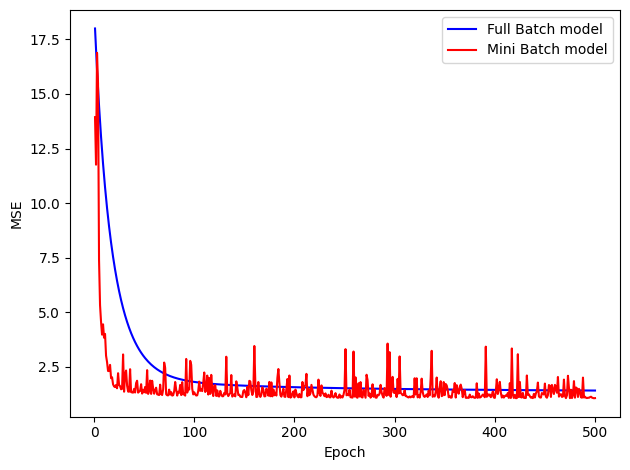

In [285]:
# Access the custom estimator FROM the pipeline
fb = full_batch_model.named_steps['regressor']  # ← critical: use step name here
mb = mini_batch_model.named_steps['regressor']

# Plot loss history
plt.plot(range(1, fb.n_iter+1), fb.losses_, label='Full Batch model', color='blue')
plt.plot(range(1, mb.n_iter+1), mb.losses_, label='Mini Batch model', color='red')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.tight_layout()
plt.legend()
#plt.savefig('figures/09_06.png', dpi=300)
plt.show()
plt.show()

### 3.2 (d)

The test set for the mini-batch model performed better for both R2 and RMSE, but not quite as well as the Scikit-Learn model. The mini-batch model has more variation as it continually updates more often. You can see on the plot the smooth curve of the full batch model, while the mini-batch model has ridges and valleys that correspond to the average error of the batches for each iteration.

# 4 Hyperparameter Optimization — Learning Rate & Batch Size

In [286]:
grid_pipeline = Pipeline([('preprocessor', preprocessor),
                        ('regressor', LinearRegressionGD(n_iter=500))])

In [287]:
# 1. Define parameter grid
param_grid = [{
    'regressor__eta': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    'regressor__batch_size': [8, 16, 32]
}]

# Used to calculate both r2 and RMSE for reporting
scoring_metrics = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error'
}



# 3. Grid search (optimizing MSE)
grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring=scoring_metrics,
    refit='r2',
    n_jobs=-1,
    verbose=1
    )

In [288]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 21 candidates, totalling 63 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...n_iter=500))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'regressor__batch_size': [8, 16, ...], 'regressor__eta': [0.0001, 0.0005, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

### 4 (a)

In [289]:
# Convert results to DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Clean up the names for the table
results_df['eta'] = results_df['param_regressor__eta']
results_df['batch_size'] = results_df['param_regressor__batch_size']

# 1. Pivot Table for Mean R2
r2_pivot = results_df.pivot(index='eta', columns='batch_size', values='mean_test_r2')

# 2. Pivot Table for Mean RMSE (Flip the sign because it was negative)
results_df['mean_test_rmse'] = -results_df['mean_test_rmse']
rmse_pivot = results_df.pivot(index='eta', columns='batch_size', values='mean_test_rmse')

print("--- Mean CV R2 Scores ---")
display(r2_pivot)

print("\n--- Mean CV RMSE Scores ---")
display(rmse_pivot)

--- Mean CV R2 Scores ---


batch_size,8,16,32
eta,,,
0.0001,-0.882374,-1.408336,-1.934966
0.0005,0.184655,0.114780,-0.204491
0.0010,-0.097438,0.065979,0.230034
0.0050,-0.383532,-0.390757,-0.238769
0.0100,-0.448045,-0.414344,-0.328934
0.0500,-0.757567,-0.700977,-0.531827
0.1000,-0.861551,-0.885850,-0.634971



--- Mean CV RMSE Scores ---


batch_size,8,16,32
eta,,,
0.0001,2.963577,3.331476,3.631072
0.0005,1.918585,2.046454,2.379884
0.0010,2.051944,1.980641,1.904459
0.0050,2.265409,2.254849,2.134254
0.0100,2.355233,2.305912,2.202927
0.0500,2.630263,2.562179,2.455220
0.1000,2.681212,2.634367,2.566354


In [ ]:
best_eta = grid_search.best_params_['regressor__eta']
best_bs = grid_search.best_params_['regressor__batch_size']
best_r2 = grid_search.best_score_
# Find the RMSE associated with that specific best index
best_index = grid_search.best_index_
best_rmse = -grid_search.cv_results_['mean_test_rmse'][best_index]

print(f"The optimal combination is eta={best_eta} and batch_size={best_bs}.")
print(f"This yielded an R2 of {best_r2:.4f} and an RMSE of {best_rmse:.4f}.")

The optimal combination is eta=0.001 and batch_size=32.
This yielded an R2 of 0.2300 and an RMSE of 1.9045.


### 4 (b)

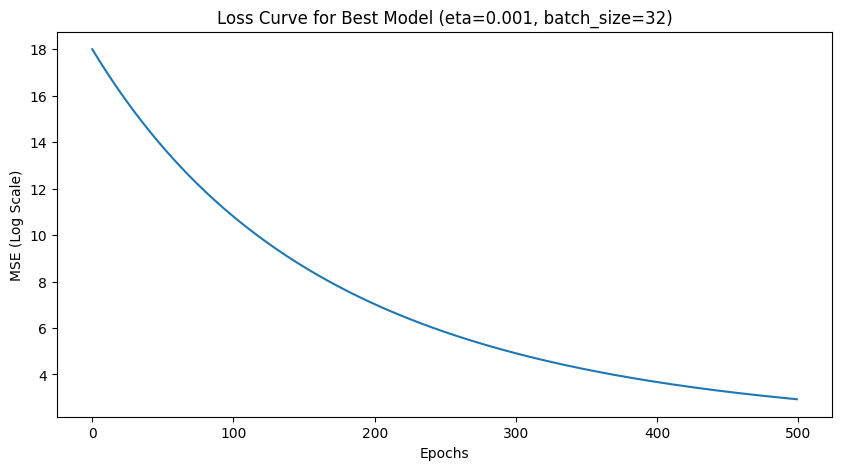

In [ ]:
best_model = grid_search.best_estimator_
best_losses = best_model.named_steps['regressor'].losses_

plt.figure(figsize=(10, 5))
plt.plot(best_losses)
plt.xlabel('Epochs')
plt.ylabel('MSE (Log Scale)')
plt.title(f"Loss Curve for Best Model (eta={grid_search.best_params_['regressor__eta']}, batch_size={grid_search.best_params_['regressor__batch_size']})")
plt.show()

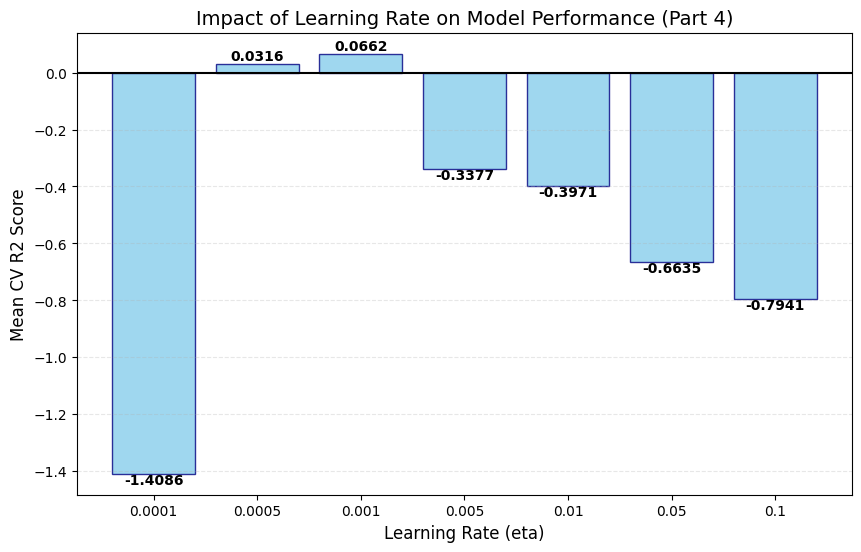

In [ ]:
eta_summary_r2 = results_df.groupby('param_regressor__eta')['mean_test_r2'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(eta_summary_r2.index.astype(str), eta_summary_r2.values, color='skyblue', edgecolor='navy', alpha=0.8)
plt.xlabel('Learning Rate (eta)', fontsize=12)
plt.ylabel('Mean CV R2 Score', fontsize=12)
plt.title('Impact of Learning Rate on Model Performance (Part 4)', fontsize=14)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')
for bar in bars:
    yval = bar.get_height()
    va_pos = 'bottom' if yval >= 0 else 'top'
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", va=va_pos, ha='center', fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

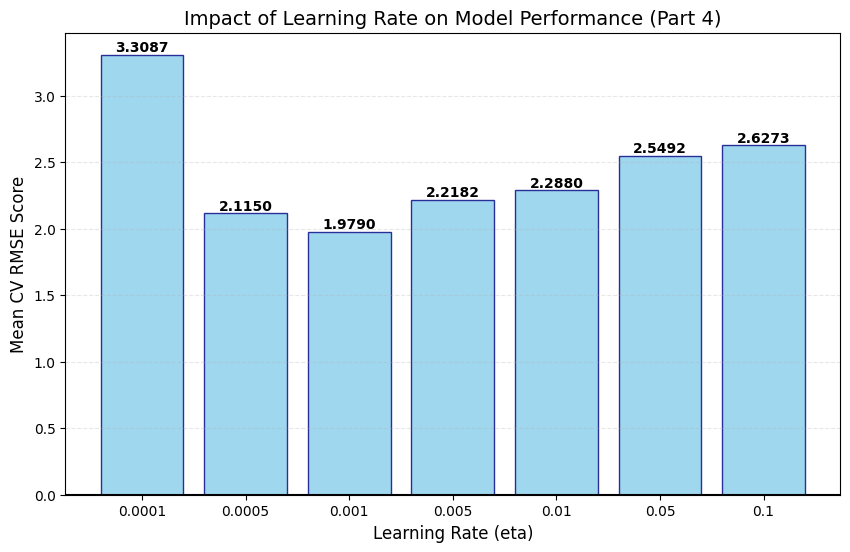

In [ ]:
eta_summary_rmse = results_df.groupby('param_regressor__eta')['mean_test_rmse'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(eta_summary_rmse.index.astype(str), eta_summary_rmse.values, color='skyblue', edgecolor='navy', alpha=0.8)
plt.xlabel('Learning Rate (eta)', fontsize=12)
plt.ylabel('Mean CV RMSE Score', fontsize=12)
plt.title('Impact of Learning Rate on Model Performance (Part 4)', fontsize=14)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')
for bar in bars:
    yval = bar.get_height()
    va_pos = 'bottom' if yval >= 0 else 'top'
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", va=va_pos, ha='center', fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### 4 (c)

In [ ]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

In [ ]:
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
best_model_r2_test = r2_score(y_test, y_test_pred)
best_model_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"R2 training score: {r2_train:.4f}")
print(f"R2 testing score: {best_model_r2_test:.4f}")
print(f"RMSE training score: {rmse_train:.4f}")
print(f"RMSE testing score: {best_model_rmse_test:.4f}")

R2 training score: 0.4471
R2 testing score: -0.7072
RMSE training score: 1.7113
RMSE testing score: 2.8944


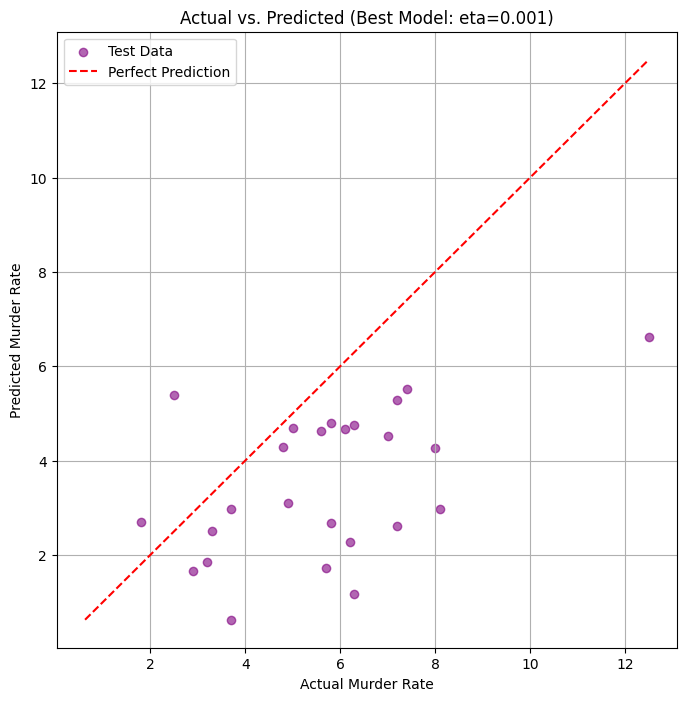

In [ ]:
plt.figure(figsize=(8, 8))

# Scatter plot of Actual vs Predicted
plt.scatter(y_test, y_test_pred, alpha=0.6, color='purple', label='Test Data')

# Create the Reference Diagonal (y=x)
# We find the min and max of the actual values to draw a line that covers the range
min_val = min(min(y_test), min(y_test_pred))
max_val = max(max(y_test), max(y_test_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Murder Rate')
plt.ylabel('Predicted Murder Rate')
plt.title(f'Actual vs. Predicted (Best Model: eta={best_eta})')
plt.legend()
plt.grid(True)
plt.show()

# 5. Model Comparison Summary

In [ ]:
summary_data = {
    'Model': ['Scikit-Learn Linear Regression 50/50 Split', 'Scikit-Learn Linear Regression 3-fold CV mean', 'Full Batch LinearRegressionGD', 'Mini Batch LinearRegressionGD', 'Mini Batch LinearRegressionGD Optimal eta and batch size'],
    'Test R2': [sklearn_test_r2_scores, sklearn_cv_r2_mean, full_batch_test_r2_scores, mini_batch_test_r2_scores, best_model_r2_test],
    'Test RMSE': [sklearn_test_rmse_scores, sklearn_cv_rmse_mean, full_batch_test_rmse_scores, mini_batch_test_rmse_scores, best_model_rmse_test]
}

summary_table = pd.DataFrame(summary_data)
display(summary_table)

,Model,Test R2,Test RMSE
0,Scikit-Learn Linear Regression 50/50 Split,0.302112,1.850588
1,Scikit-Learn Linear Regression 3-fold CV mean,-0.723489,2.656236
2,Full Batch LinearRegressionGD,0.179576,2.006486
3,Mini Batch LinearRegressionGD,0.250568,1.917711
4,Mini Batch LinearRegressionGD Optimal eta and ...,-0.707170,2.894378


The model that performed the best was the Scikit-Learn LinearRegression with 50/50 train test split. This suggests that hyperparameter tuning can only perform so well - especially with small datasets - and can lead to overfitting. The Scikit-Learn model uses a mathmatical formula to find the minimum while our gradient descent version slowly "learns" the minimum by taking small steps towords it and is highly sensitive to the hyperparameters such as learning rate and batch size. Since the model is obviously overfit, the next thing we would pursue is some form of regularization such as Lasso that give a penalty to weights that are less important.

# Discussion & Reflection

### a) What do you believe you did well on this assignment?

### b) What was the most challenging part of this assignment?

### c) What would have made this assignment a better learning experience?

### d) What do you need help with going forward?
